# Team Members & Contributions:

Iain: Introduction, Data Collection / EDA, plots, slides

Diego: Obtained demographic data and completed the EDA section for it.

Christina: EDA, Research Question 1 analysis and plots, slides

John: Introduction, Data, Conclusion, slides

# Research Questions

1. How do air quality patterns, as measured through the mean Air Quality Index scores, differ between coastal and inland regions of San Diego county, with coastal regions being measured as the zip codes that contain the coast and inland regions being measured as zip codes that do not contain the coast? 
2. Is there a correlation between the air quality patterns, as measured through the mean Air Quality Index scores, and disparities in health outcomes, as measured by rates of asthma in each zip code, when controlling for other variables (income, median age, etc.)?

# Data Collection and Exploration

In [102]:
# Import necessary packages
#%pip install pgeocode
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
import scipy.stats as stats
import pingouin as pg
import pgeocode
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm

First, in order to answer our research questions, we need data on the Air Quality Index scores for each region of San Diego. We found that IQAir, an air quality data resource, has an API on their website for the air quality index scores for each region in San Diego. However, requesting an ID for the API is taking some time, so in the meantime, we have manually obtained some data from the website.

## Wrangling AQI Data

In [103]:
file_path = 'aqi_data.csv'
aqi_df = pd.read_csv(file_path)
aqi_df.head()

,Date,Source,Site ID,POC,Daily Max 8-hour Ozone Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2021,AQS,60730001,1,0.040,ppm,37,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
1,01/02/2021,AQS,60730001,1,0.038,ppm,35,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
2,01/03/2021,AQS,60730001,1,0.041,ppm,38,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
3,01/04/2021,AQS,60730001,1,0.039,ppm,36,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088
4,01/05/2021,AQS,60730001,1,0.034,ppm,31,Chula Vista,17,100.0,...,Ozone,47.0,41740,"San Diego-Carlsbad, CA",6,California,73,San Diego,32.631242,-117.059088


In [104]:
aqi_df.columns

Index(['Date', 'Source', 'Site ID', 'POC',
       'Daily Max 8-hour Ozone Concentration', 'Units', 'Daily AQI Value',
       'Local Site Name', 'Daily Obs Count', 'Percent Complete',
       'AQS Parameter Code', 'AQS Parameter Description', 'Method Code',
       'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
      dtype='object')

First, let's simplify the dataset by only selecting the columns relevant for our data analysis, and also change date into a pd DateTime object.

In [105]:
aqi_df = aqi_df[['Date', 'Site ID', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count', 'Site Latitude', 'Site Longitude']]

aqi_df['Date'] = pd.to_datetime(aqi_df['Date'])

Next, let us add a column to label the sites as being coastal or inland.

In [106]:
coastal_stations = [
    "Chula Vista",
    "Camp Pendleton",
    "San Diego - Sherman Elementary School"
]


urban_stations = [
    "San Diego - Kearny Villa Rd.",
    "El Cajon - Lexington Elementary School",
    "Donovan"
]

inland_stations = [
    "Alpine",
    "Pala Airpad",
    "La Posta Band of Indians"
]

aqi_df['Coastal'] = np.where(aqi_df['Local Site Name'].isin(coastal_stations), 1, 0)
aqi_df['Inland'] = np.where(aqi_df['Local Site Name'].isin(inland_stations), 1, 0)
aqi_df.head()

,Date,Site ID,Daily AQI Value,Local Site Name,Daily Obs Count,Site Latitude,Site Longitude,Coastal,Inland
0,2021-01-01,60730001,37,Chula Vista,17,32.631242,-117.059088,1,0
1,2021-01-02,60730001,35,Chula Vista,17,32.631242,-117.059088,1,0
2,2021-01-03,60730001,38,Chula Vista,17,32.631242,-117.059088,1,0
3,2021-01-04,60730001,36,Chula Vista,17,32.631242,-117.059088,1,0
4,2021-01-05,60730001,31,Chula Vista,17,32.631242,-117.059088,1,0


## EDA for AQI Data

In [107]:
aqi_df.describe()

,Date,Site ID,Daily AQI Value,Daily Obs Count,Site Latitude,Site Longitude,Coastal,Inland
count,14489,1.448900e+04,14489.000000,14489.000000,14489.000000,14489.000000,14489.000000,14489.000000
mean,2023-06-25 12:29:39.998619392,6.073153e+07,42.953965,17.634343,32.860506,-117.008677,0.345780,0.301194
min,2021-01-01 00:00:00,6.073000e+07,0.000000,13.000000,32.578165,-117.396249,0.000000,0.000000
25%,2022-04-17 00:00:00,6.073101e+07,35.000000,17.000000,32.710177,-117.123964,0.000000,0.000000
50%,2023-07-08 00:00:00,6.073102e+07,41.000000,17.000000,32.789565,-117.059088,0.000000,0.000000
75%,2024-08-30 00:00:00,6.073103e+07,46.000000,17.000000,32.845709,-116.921374,1.000000,1.000000
max,2025-12-09 00:00:00,6.073999e+07,161.000000,24.000000,33.362593,-116.364410,1.000000,1.000000
std,NaN,2.288300e+03,15.529692,2.651911,0.251168,0.241643,0.475638,0.458793


In [108]:
stations_per_day = aqi_df.groupby('Date')['Local Site Name'].nunique()
stations_per_day.describe()

count    1800.000000
mean        8.049444
std         0.850269
min         4.000000
25%         8.000000
50%         8.000000
75%         9.000000
max         9.000000
Name: Local Site Name, dtype: float64

In [109]:
pivot = aqi_df.pivot_table(
    index='Date',
    columns='Local Site Name',
    values='Daily AQI Value'
)

In [110]:
pivot['County Mean AQI'] = pivot.mean(axis=1)

Text(0, 0.5, 'AQI')

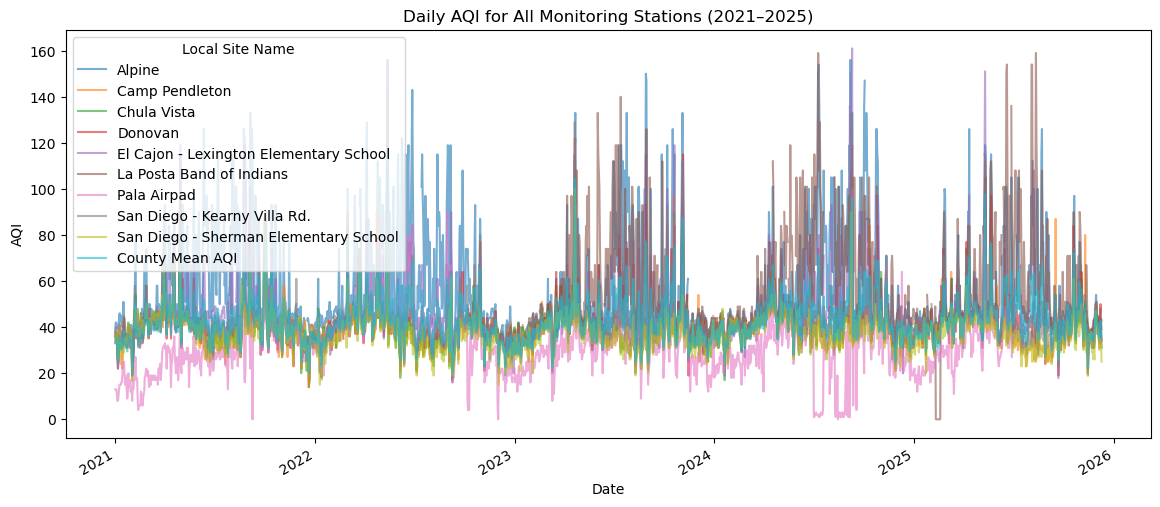

In [111]:
pivot.plot(figsize=(14,6), alpha=0.6)
plt.title("Daily AQI for All Monitoring Stations (2021–2025)")
plt.ylabel("AQI")

<Axes: xlabel='Month'>

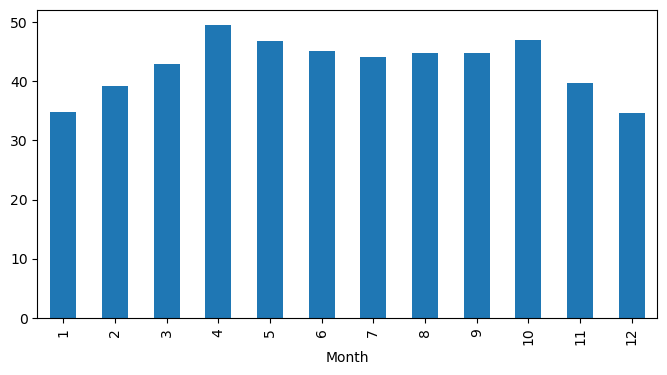

In [112]:
## Mean AQI by Month
pivot['Month'] = pivot.index.month
pivot.groupby('Month')['County Mean AQI'].mean().plot(kind='bar')

In [113]:
pivot['7d'] = pivot['County Mean AQI'].rolling(7).mean()
pivot['30d'] = pivot['County Mean AQI'].rolling(30).mean()

heavy_days = pivot[pivot['County Mean AQI'] > 100]

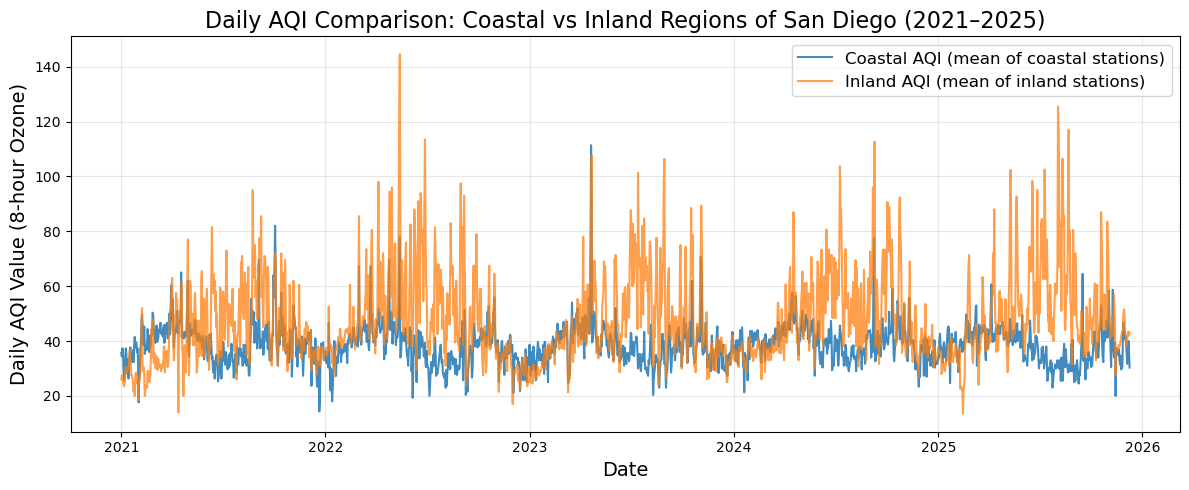

In [114]:
coastal = pivot[coastal_stations].mean(axis=1)
inland  = pivot[inland_stations].mean(axis=1)

coastal_smooth = coastal.rolling(window=7, center=True).mean()
inland_smooth = inland.rolling(window=7, center=True).mean()

plt.figure(figsize=(12,5))

plt.plot(coastal, label="Coastal AQI (mean of coastal stations)", alpha=0.85)
plt.plot(inland, label="Inland AQI (mean of inland stations)", alpha=0.75)

plt.title("Daily AQI Comparison: Coastal vs Inland Regions of San Diego (2021–2025)", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Daily AQI Value (8-hour Ozone)", fontsize=14)

plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [115]:
## Coastal vs Inland (including urban)
coastal_urban_stations = [
    'Chula Vista',
    'Camp Pendleton',
    'San Diego - Sherman Elementary School'
]

inland_urban_stations = [
    'Alpine',
    'Pala Airpad',
    'La Posta Band of Indians',
    'El Cajon - Lexington Elementary School',
    'Donovan'
]

coastal_urban = pivot[coastal_urban_stations].mean(axis=1)
inland_urban = pivot[inland_urban_stations].mean(axis=1)

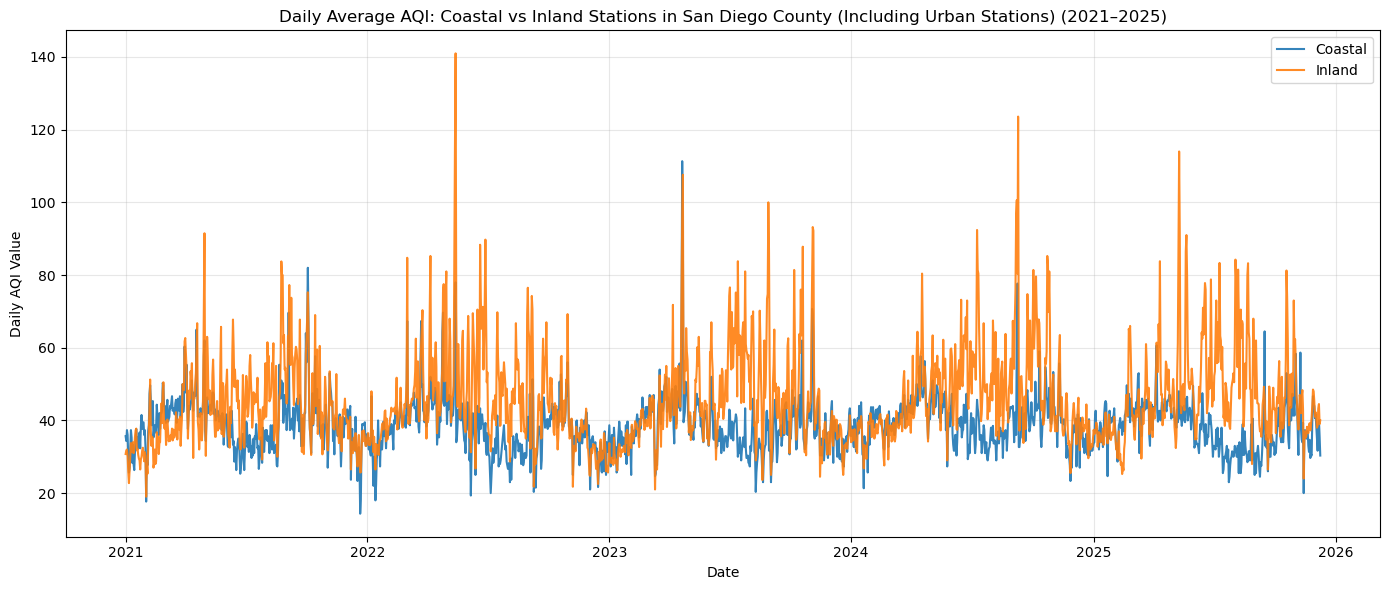

In [116]:
plt.figure(figsize=(14,6))
plt.plot(coastal_urban.index, coastal_urban, label="Coastal", alpha=0.9)
plt.plot(inland_urban.index, inland_urban, label="Inland", alpha=0.9)

plt.title("Daily Average AQI: Coastal vs Inland Stations in San Diego County (Including Urban Stations) (2021–2025)")
plt.xlabel("Date")
plt.ylabel("Daily AQI Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [117]:
pivot.isna().sum().sort_values().drop(['County Mean AQI', 'Month', '7d', '30d'])

Local Site Name
San Diego - Sherman Elementary School      34
Alpine                                     39
San Diego - Kearny Villa Rd.               41
Donovan                                    53
Camp Pendleton                            119
Pala Airpad                               165
El Cajon - Lexington Elementary School    191
Chula Vista                               237
La Posta Band of Indians                  832
dtype: int64

## Obtaining and Cleaning Demographic Data

In [118]:
## Loading packages
#pip install census requests us
import os
import pandas as pd
import numpy as np
from census import Census
from us import states
import requests
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

In [119]:
# Census API key
plt.rcParams["figure.figsize"] = (8, 4)

# --- keys & constants ---
CENSUS_API_KEY = "ce8b9610a02a2db4fd9e5ccb0412895621293667"
c = Census(CENSUS_API_KEY)

In [120]:
STATE_FIPS = states.CA.fips          # '06'
SAN_DIEGO_COUNTY_FIPS = "073"        # San Diego County
START_YEAR = 2018
END_YEAR = 2023

# folder for any local CSVs you download
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

In [121]:
## Get Census data by zipcode

ACS_VARS = {
    "B01003_001E": "pop_total",
    "B19013_001E": "med_income",
    "B01002_001E": "med_age",
    "B02001_002E": "white_alone",
    "B02001_003E": "black_alone",
    "B02001_005E": "asian_alone",
    "B03002_012E": "hispanic_any",
    "B17001_002E": "pop_below_poverty",
}

acs_cols = tuple(ACS_VARS.keys()) + ("NAME",)

STATE_FIPS = states.CA.fips  # "06"

# Pull ALL ZCTAs in California
zcta_raw = c.acs5.state_zipcode(
    acs_cols,
    STATE_FIPS,
    Census.ALL
)

acs_zip = pd.DataFrame(zcta_raw).rename(columns=ACS_VARS)

# Rename + format ZIP/ZCTA key
acs_zip.rename(columns={"zip code tabulation area": "Zip_Code"}, inplace=True)
acs_zip["Zip_Code"] = acs_zip["Zip_Code"].astype(str).str.zfill(5)

# Make sure numeric cols are numeric (API often returns strings)
num_cols = list(ACS_VARS.values())
acs_zip[num_cols] = acs_zip[num_cols].apply(pd.to_numeric, errors="coerce")

# Fractions
acs_zip["p_white"] = acs_zip["white_alone"] / acs_zip["pop_total"]
acs_zip["p_black"] = acs_zip["black_alone"] / acs_zip["pop_total"]
acs_zip["p_asian"] = acs_zip["asian_alone"] / acs_zip["pop_total"]
acs_zip["p_hispanic"] = acs_zip["hispanic_any"] / acs_zip["pop_total"]
acs_zip["p_poverty"] = acs_zip["pop_below_poverty"] / acs_zip["pop_total"]

In [122]:
## Reduce Census Dataset to Zip Codes Associated With San Diego County
asthma = pd.read_csv('asthma.csv')

asthma_sd = asthma[asthma['County'] == 'San Diego']
asthma_sd["Zip_Code"] = asthma_sd["Zip_Code"].astype(str).str.zfill(5)

acs_zip = acs_zip[acs_zip["Zip_Code"].isin(asthma_sd["Zip_Code"].unique())]
acs_zip.head(10)

/tmp/ipykernel_312/2224539920.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  asthma_sd["Zip_Code"] = asthma_sd["Zip_Code"].astype(str).str.zfill(5)


,pop_total,med_income,med_age,white_alone,black_alone,asian_alone,hispanic_any,pop_below_poverty,NAME,Zip_Code,p_white,p_black,p_asian,p_hispanic,p_poverty
30905,18300.0,116600.0,42.5,14504.0,310.0,474.0,3397.0,1845.0,ZCTA5 91901,91901,0.792568,0.016940,0.025902,0.185628,0.100820
30906,17445.0,121727.0,46.9,7318.0,255.0,2578.0,8241.0,1017.0,ZCTA5 91902,91902,0.419490,0.014617,0.147779,0.472399,0.058298
30908,3375.0,58561.0,44.9,2235.0,204.0,15.0,1016.0,507.0,ZCTA5 91906,91906,0.662222,0.060444,0.004444,0.301037,0.150222
30909,77957.0,87705.0,38.4,28568.0,2888.0,8215.0,50129.0,7978.0,ZCTA5 91910,91910,0.366458,0.037046,0.105379,0.643034,0.102338
30910,84619.0,79334.0,36.7,28566.0,3447.0,6106.0,63244.0,8862.0,ZCTA5 91911,91911,0.337584,0.040736,0.072159,0.747397,0.104728
30911,57067.0,129412.0,35.6,14377.0,4767.0,15044.0,27003.0,3281.0,ZCTA5 91913,91913,0.251932,0.083533,0.263620,0.473181,0.057494
30912,17036.0,164398.0,38.4,6606.0,550.0,3065.0,8916.0,626.0,ZCTA5 91914,91914,0.387767,0.032285,0.179913,0.523362,0.036746
30913,35385.0,138283.0,34.9,10726.0,2853.0,8166.0,15405.0,2111.0,ZCTA5 91915,91915,0.303123,0.080627,0.230776,0.435354,0.059658
30917,25897.0,79071.0,35.2,12669.0,1185.0,1765.0,13145.0,3938.0,ZCTA5 91932,91932,0.489207,0.045758,0.068155,0.507588,0.152064
30919,9466.0,138953.0,45.7,7153.0,76.0,136.0,2281.0,315.0,ZCTA5 91935,91935,0.755652,0.008029,0.014367,0.240968,0.033277


In [123]:
acs_zip.to_csv("data/demographics_zipcode.csv", index=False)

In [124]:
## Get Census Data by Tract
ACS_VARS = {
    "B01003_001E": "pop_total",
    "B19013_001E": "med_income",
    "B01002_001E": "med_age",
    "B02001_002E": "white_alone",
    "B02001_003E": "black_alone",
    "B02001_005E": "asian_alone",
    "B03002_012E": "hispanic_any",
    "B17001_002E": "pop_below_poverty",
}

acs_cols = tuple(ACS_VARS.keys()) + ("NAME",)


tracts_raw = c.acs5.state_county_tract(
    acs_cols,
    STATE_FIPS,
    SAN_DIEGO_COUNTY_FIPS,
    Census.ALL
)

acs = pd.DataFrame(tracts_raw)
acs.rename(columns=ACS_VARS, inplace=True)


acs["GEOID"] = acs["state"] + acs["county"] + acs["tract"]


acs["p_white"] = acs["white_alone"] / acs["pop_total"]
acs["p_black"] = acs["black_alone"] / acs["pop_total"]
acs["p_asian"] = acs["asian_alone"] / acs["pop_total"]
acs["p_hispanic"] = acs["hispanic_any"] / acs["pop_total"]
acs["p_poverty"] = acs["pop_below_poverty"] / acs["pop_total"]

acs.head()

,pop_total,med_income,med_age,white_alone,black_alone,asian_alone,hispanic_any,pop_below_poverty,NAME,state,county,tract,GEOID,p_white,p_black,p_asian,p_hispanic,p_poverty
0,2746.0,211023.0,52.5,2282.0,36.0,136.0,300.0,46.0,Census Tract 1; San Diego County; California,06,073,000100,06073000100,0.831027,0.013110,0.049527,0.109250,0.016752
1,2376.0,110476.0,49.9,2082.0,0.0,136.0,82.0,210.0,Census Tract 2.01; San Diego County; California,06,073,000201,06073000201,0.876263,0.000000,0.057239,0.034512,0.088384
2,4019.0,121264.0,41.9,3297.0,29.0,184.0,769.0,158.0,Census Tract 2.02; San Diego County; California,06,073,000202,06073000202,0.820353,0.007216,0.045783,0.191341,0.039313
3,2487.0,79605.0,39.6,1771.0,22.0,131.0,531.0,386.0,Census Tract 3.01; San Diego County; California,06,073,000301,06073000301,0.712103,0.008846,0.052674,0.213510,0.155207
4,2925.0,89850.0,44.0,2135.0,113.0,188.0,554.0,277.0,Census Tract 3.02; San Diego County; California,06,073,000302,06073000302,0.729915,0.038632,0.064274,0.189402,0.094701


In [125]:
# Classify tracts as coastal or inland based on distance from tract centroids to the coast

def get_tract_centroids(state_fips="06", county_fips="073"):
    layer = 10  # Census Tracts layer
    url = (
        f"https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/Tracts_Blocks/MapServer/{layer}/query"
        f"?where=STATE+%3D+'{state_fips}'+AND+COUNTY+%3D+'{county_fips}'"
        f"&outFields=STATE,COUNTY,TRACT"
        f"&returnGeometry=true&geometryPrecision=6&outSR=4326"
        f"&f=json"
    )

    resp = requests.get(url).json()

    if "features" not in resp:
        print("API returned an error:", resp)
        raise ValueError("TIGERweb query failed")

    rows = []

    for feat in resp["features"]:
        attrs = feat["attributes"]
        geom = feat["geometry"]["rings"][0]

        xs = [p[0] for p in geom]
        ys = [p[1] for p in geom]
        lon = sum(xs) / len(xs)
        lat = sum(ys) / len(ys)

        rows.append({
            "STATE": attrs["STATE"],
            "COUNTY": attrs["COUNTY"],
            "TRACT": attrs["TRACT"],
            "centroid_lon": lon,
            "centroid_lat": lat
        })

    return pd.DataFrame(rows)

centroids = get_tract_centroids()
centroids["GEOID"] = centroids["STATE"] + centroids["COUNTY"] + centroids["TRACT"]

In [126]:
acs = acs.merge(centroids, on="GEOID", how="left")

acs["region"] = acs["centroid_lon"].apply(
    lambda x: "coastal" if x > -117.25 else "inland"
)

acs["region"].value_counts()

region
coastal    631
inland     106
Name: count, dtype: int64

In [127]:
## Checking for bad data

acs.isnull().sum().sum()

10

## EDA for Demographic Data

In [128]:
acs.columns

Index(['pop_total', 'med_income', 'med_age', 'white_alone', 'black_alone',
       'asian_alone', 'hispanic_any', 'pop_below_poverty', 'NAME', 'state',
       'county', 'tract', 'GEOID', 'p_white', 'p_black', 'p_asian',
       'p_hispanic', 'p_poverty', 'STATE', 'COUNTY', 'TRACT', 'centroid_lon',
       'centroid_lat', 'region'],
      dtype='object')

In [129]:
acs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737 entries, 0 to 736
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pop_total          737 non-null    float64
 1   med_income         737 non-null    float64
 2   med_age            737 non-null    float64
 3   white_alone        737 non-null    float64
 4   black_alone        737 non-null    float64
 5   asian_alone        737 non-null    float64
 6   hispanic_any       737 non-null    float64
 7   pop_below_poverty  737 non-null    float64
 8   NAME               737 non-null    object 
 9   state              737 non-null    object 
 10  county             737 non-null    object 
 11  tract              737 non-null    object 
 12  GEOID              737 non-null    object 
 13  p_white            735 non-null    float64
 14  p_black            735 non-null    float64
 15  p_asian            735 non-null    float64
 16  p_hispanic         735 non

In [130]:
acs.describe()

,pop_total,med_income,med_age,white_alone,black_alone,asian_alone,hispanic_any,pop_below_poverty,p_white,p_black,p_asian,p_hispanic,p_poverty,centroid_lon,centroid_lat
count,737.000000,7.370000e+02,7.370000e+02,737.000000,737.000000,737.000000,737.000000,737.000000,735.000000,735.000000,735.000000,735.000000,735.000000,737.000000,737.000000
mean,4454.249661,-7.126849e+06,-1.809097e+06,2361.221167,209.763908,544.175034,1529.472185,448.578019,0.544824,0.045894,0.115042,0.333832,0.100221,-117.113063,32.876123
std,2107.362836,6.913806e+07,3.470522e+07,1324.373218,290.434759,666.332208,1278.671273,383.925575,0.188517,0.055203,0.119664,0.221480,0.075277,0.130598,0.200816
min,0.000000,-6.666667e+08,-6.666667e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.072311,0.000000,0.000000,0.000000,0.000000,-117.389645,32.546651
25%,3313.000000,7.744400e+04,3.400000e+01,1586.000000,40.000000,134.000000,611.000000,174.000000,0.390616,0.009314,0.036115,0.158631,0.048073,-117.209949,32.725521
50%,4257.000000,1.036170e+05,3.840000e+01,2202.000000,107.000000,300.000000,1185.000000,338.000000,0.557272,0.027451,0.071991,0.272112,0.079747,-117.110025,32.808973
75%,5436.000000,1.343580e+05,4.270000e+01,2893.000000,269.000000,645.000000,2071.000000,603.000000,0.704600,0.061019,0.144099,0.477326,0.132184,-117.043736,33.038351
max,40481.000000,2.500010e+05,7.310000e+01,22239.000000,3760.000000,5653.000000,13887.000000,3370.000000,0.905005,0.440678,0.642278,0.959959,0.427508,-116.381106,33.412082


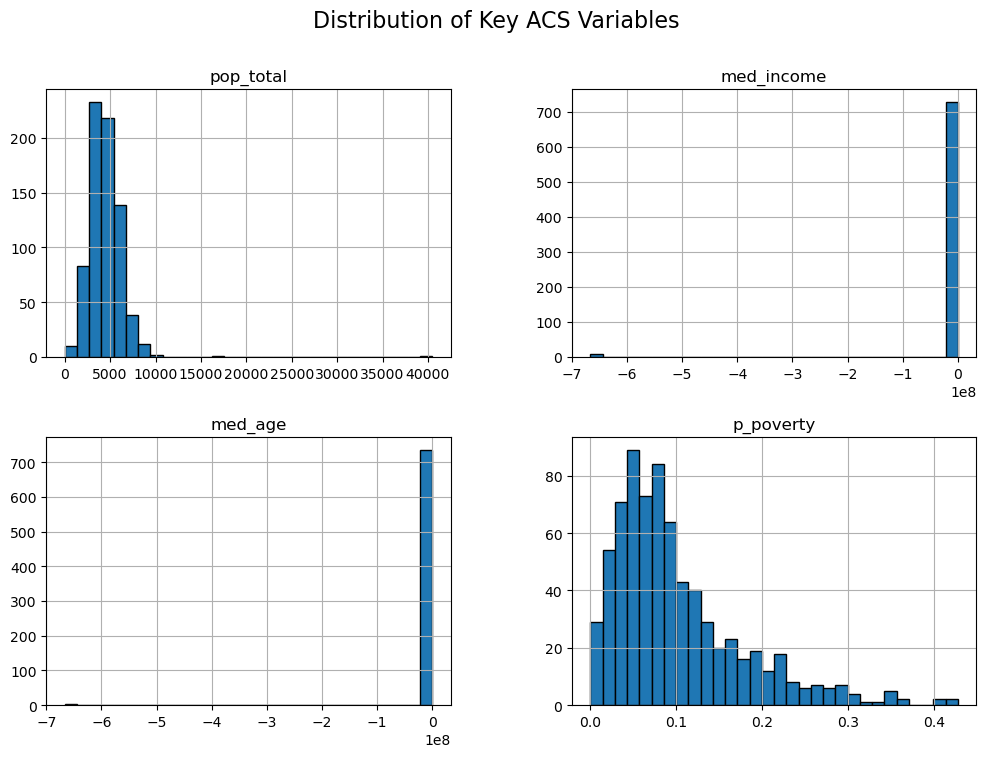

In [131]:
num_cols = ["pop_total", "med_income", "med_age", "p_poverty"]

acs[num_cols].hist(bins=30, figsize=(12, 8), edgecolor="black")
plt.suptitle("Distribution of Key ACS Variables", fontsize=16)
plt.show()

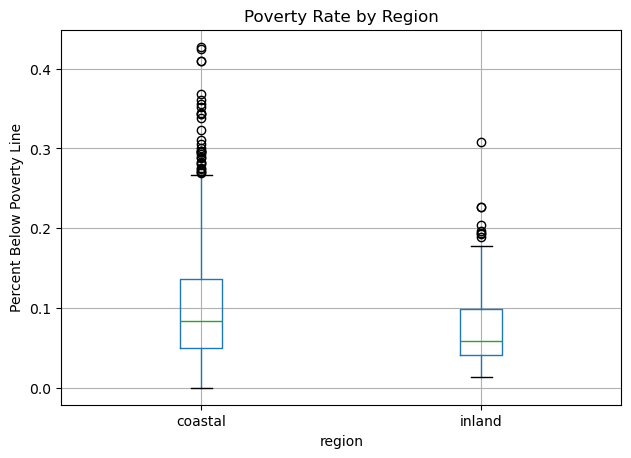

In [132]:
acs.boxplot(column="p_poverty", by="region", figsize=(7,5))
plt.title("Poverty Rate by Region")
plt.suptitle("")
plt.ylabel("Percent Below Poverty Line")
plt.show()

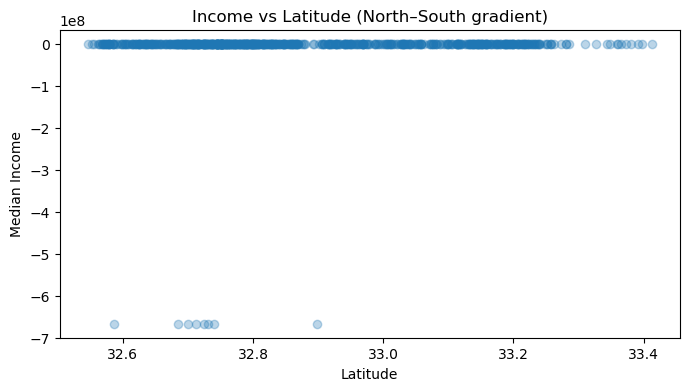

In [133]:
plt.scatter(acs["centroid_lat"], acs["med_income"], alpha=0.3)
plt.xlabel("Latitude")
plt.ylabel("Median Income")
plt.title("Income vs Latitude (North–South gradient)")
plt.show()

In [134]:
acs[(acs['med_income'] < 0) | (acs['med_age'] < 0)]

,pop_total,med_income,med_age,white_alone,black_alone,asian_alone,hispanic_any,pop_below_poverty,NAME,state,...,p_black,p_asian,p_hispanic,p_poverty,STATE,COUNTY,TRACT,centroid_lon,centroid_lat,region
90,8774.0,-666666666.0,24.8,4492.0,1621.0,1060.0,2034.0,0.0,Census Tract 38; San Diego County; California,06,...,0.184750,0.120811,0.231821,0.0,06,073,003800,-117.124220,32.685547,coastal
115,295.0,-666666666.0,20.9,119.0,130.0,0.0,57.0,0.0,Census Tract 55; San Diego County; California,06,...,0.440678,0.000000,0.193220,0.0,06,073,005500,-117.146953,32.724275,coastal
124,31.0,-666666666.0,20.5,16.0,7.0,0.0,0.0,0.0,Census Tract 62; San Diego County; California,06,...,0.225806,0.000000,0.000000,0.0,06,073,006200,-117.192883,32.730803,coastal
125,2490.0,-666666666.0,20.3,1542.0,221.0,141.0,880.0,0.0,Census Tract 63; San Diego County; California,06,...,0.088755,0.056627,0.353414,0.0,06,073,006300,-117.197218,32.739942,coastal
268,1462.0,-666666666.0,30.1,987.0,91.0,199.0,406.0,0.0,Census Tract 99.01; San Diego County; California,06,...,0.062244,0.136115,0.277702,0.0,06,073,009901,-117.245466,32.699636,coastal
269,0.0,-666666666.0,-666666666.0,0.0,0.0,0.0,0.0,0.0,Census Tract 99.02; San Diego County; California,06,...,NaN,NaN,NaN,NaN,06,073,009902,-117.212779,32.711843,coastal
280,3217.0,-666666666.0,41.6,1426.0,940.0,69.0,1417.0,0.0,Census Tract 100.16; San Diego County; California,06,...,0.292198,0.021449,0.440472,0.0,06,073,010016,-116.969576,32.586191,coastal
736,0.0,-666666666.0,-666666666.0,0.0,0.0,0.0,0.0,0.0,Census Tract 9901; San Diego County; California,06,...,NaN,NaN,NaN,NaN,06,073,990100,-117.310319,32.898249,inland


While there are very few missing values, some tracts have too low of a population and/or its estimates for median income and median age were too unreliable, that's why a lot of these plots look so skewed, therefore the 8 rows above will be dropped.

In [135]:
bad_rows = acs[(acs['med_income'] < 0) | (acs['med_age'] < 0)]
acs = acs[~((acs['med_income'] < 0) | (acs['med_age'] < 0))].copy()

In [136]:
acs.describe()

,pop_total,med_income,med_age,white_alone,black_alone,asian_alone,hispanic_any,pop_below_poverty,p_white,p_black,p_asian,p_hispanic,p_poverty,centroid_lon,centroid_lat
count,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000,729.000000
mean,4480.813443,110899.813443,38.995885,2375.360768,207.936900,548.131687,1539.680384,453.500686,0.544961,0.044496,0.115529,0.334526,0.101046,-117.112384,32.877814
std,2082.929523,43742.453936,7.150089,1316.171214,285.660876,667.961366,1279.673597,383.122847,0.189093,0.051955,0.119932,0.221906,0.075032,0.130779,0.201085
min,889.000000,24125.000000,17.100000,240.000000,0.000000,0.000000,46.000000,0.000000,0.072311,0.000000,0.000000,0.021289,0.000000,-117.389645,32.546651
25%,3319.000000,78516.000000,34.100000,1596.000000,40.000000,135.000000,623.000000,184.000000,0.388759,0.009199,0.036488,0.158531,0.048909,-117.208351,32.727548
50%,4273.000000,104457.000000,38.500000,2208.000000,107.000000,305.000000,1187.000000,342.000000,0.557307,0.026870,0.072070,0.272112,0.080158,-117.108433,32.811934
75%,5442.000000,135000.000000,42.700000,2909.000000,269.000000,647.000000,2083.000000,606.000000,0.706202,0.060272,0.144307,0.480417,0.134254,-117.043326,33.040676
max,40481.000000,250001.000000,73.100000,22239.000000,3760.000000,5653.000000,13887.000000,3370.000000,0.905005,0.283006,0.642278,0.959959,0.427508,-116.381106,33.412082


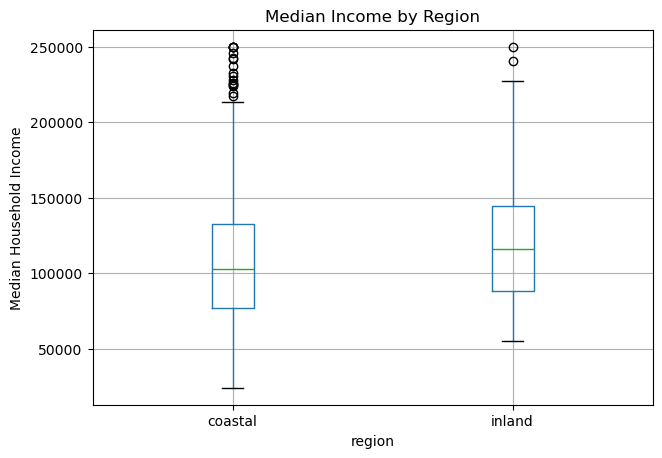

In [137]:
acs.boxplot(column="med_income", by="region", figsize=(7,5))
plt.title("Median Income by Region")
plt.suptitle("")
plt.ylabel("Median Household Income")
plt.show()

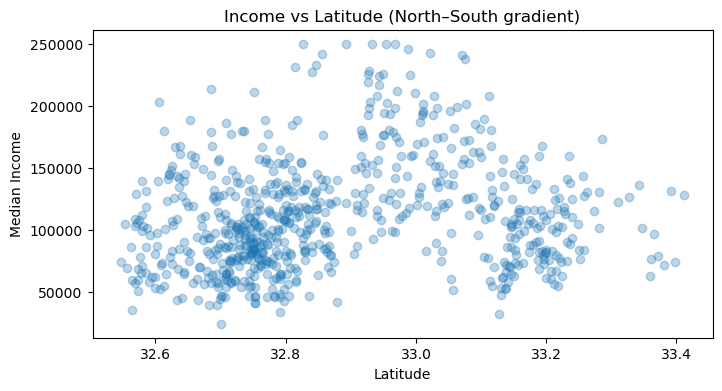

In [138]:
plt.scatter(acs["centroid_lat"], acs["med_income"], alpha=0.3)
plt.xlabel("Latitude")
plt.ylabel("Median Income")
plt.title("Income vs Latitude (North–South gradient)")
plt.show()

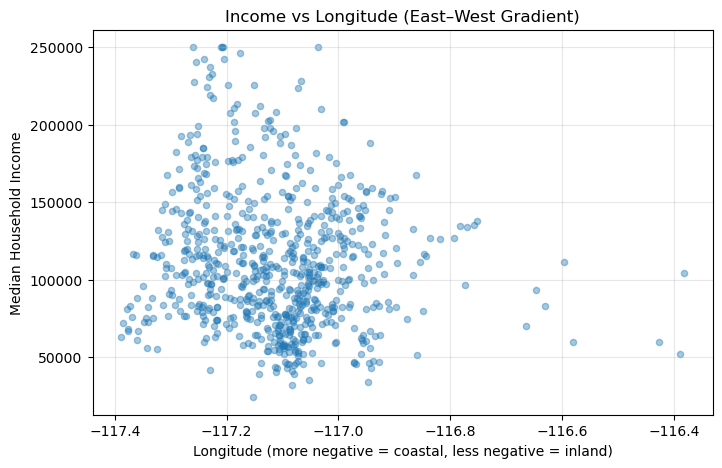

In [139]:
plt.figure(figsize=(8, 5))

plt.scatter(
    acs["centroid_lon"],
    acs["med_income"],
    alpha=0.4,
    s=20
)

plt.xlabel("Longitude (more negative = coastal, less negative = inland)")
plt.ylabel("Median Household Income")
plt.title("Income vs Longitude (East–West Gradient)")

plt.grid(True, alpha=0.3)
plt.show()

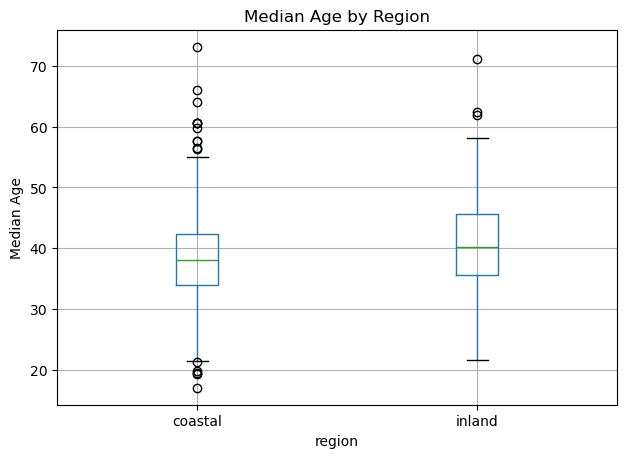

In [140]:
acs.boxplot(column="med_age", by="region", figsize=(7,5))
plt.title("Median Age by Region")
plt.suptitle("")
plt.ylabel("Median Age")
plt.show()

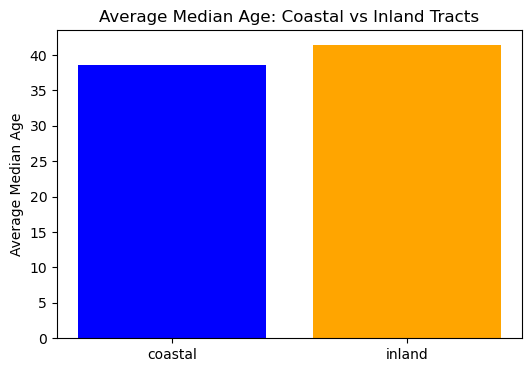

In [141]:
avg_age = acs.groupby("region")["med_age"].mean().reset_index()

plt.figure(figsize=(6,4))
plt.bar(avg_age["region"], avg_age["med_age"], color=["blue", "orange"])
plt.ylabel("Average Median Age")
plt.title("Average Median Age: Coastal vs Inland Tracts")
plt.show()

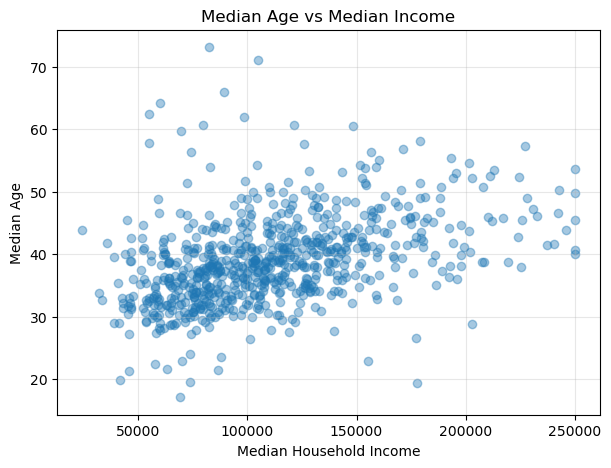

In [142]:
plt.figure(figsize=(7,5))
plt.scatter(acs["med_income"], acs["med_age"], alpha=0.4)
plt.xlabel("Median Household Income")
plt.ylabel("Median Age")
plt.title("Median Age vs Median Income")
plt.grid(alpha=0.3)
plt.show()

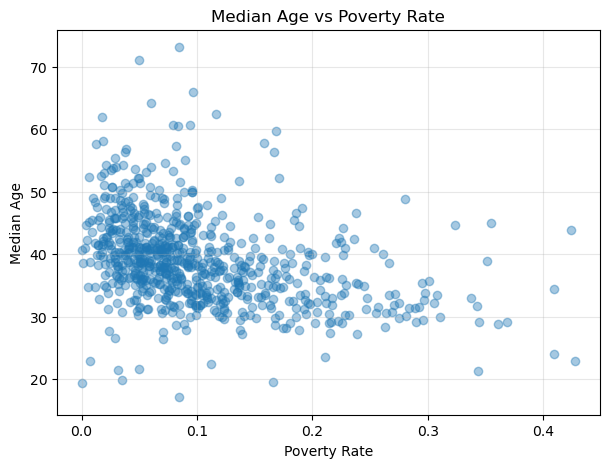

In [143]:
plt.figure(figsize=(7,5))
plt.scatter(acs["p_poverty"], acs["med_age"], alpha=0.4)
plt.xlabel("Poverty Rate")
plt.ylabel("Median Age")
plt.title("Median Age vs Poverty Rate")
plt.grid(alpha=0.3)
plt.show()

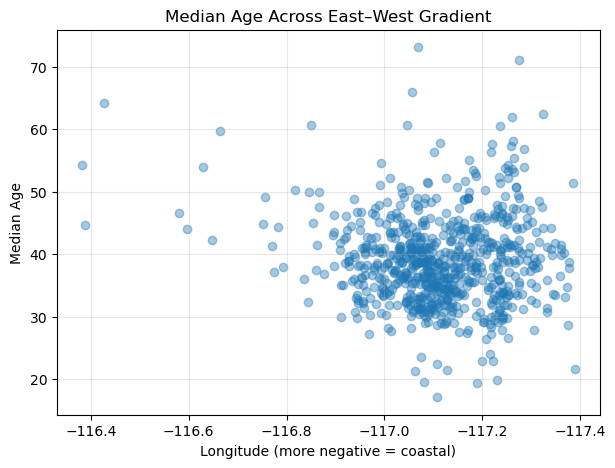

In [144]:
plt.figure(figsize=(7,5))
plt.scatter(acs["centroid_lon"], acs["med_age"], alpha=0.4)
plt.xlabel("Longitude (more negative = coastal)")
plt.ylabel("Median Age")
plt.title("Median Age Across East–West Gradient")
plt.grid(alpha=0.3)
plt.gca().invert_xaxis()  # makes coastline appear on the left
plt.show()

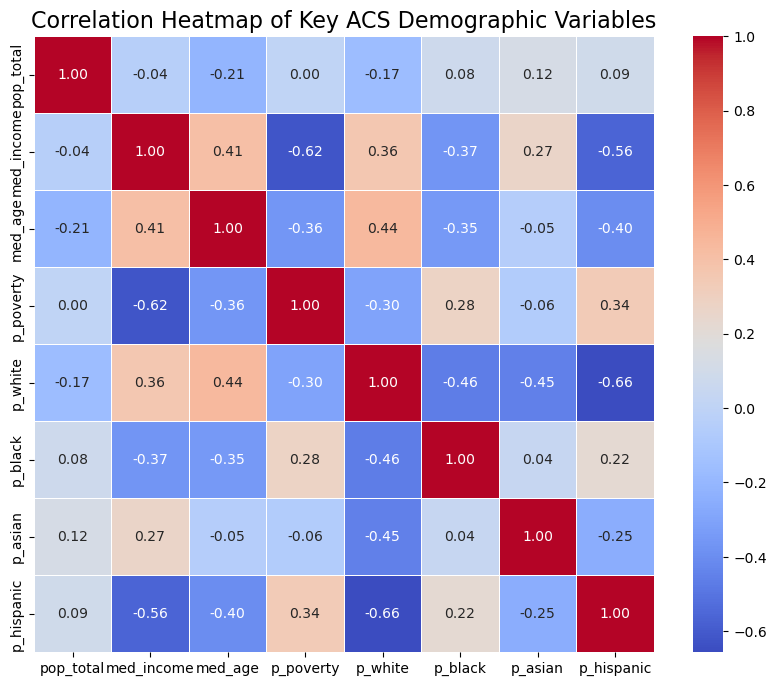

In [145]:
corr_cols = [
    "pop_total",
    "med_income",
    "med_age",
    "p_poverty",
    "p_white",
    "p_black",
    "p_asian",
    "p_hispanic"
]

# Compute correlation matrix
corr_matrix = acs[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    linewidths=0.5
)
plt.title("Correlation Heatmap of Key ACS Demographic Variables", fontsize=16)
plt.show()

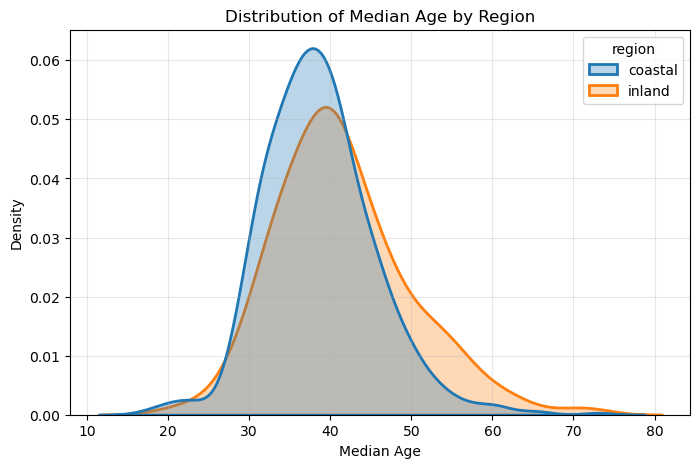

In [146]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=acs,
    x="med_age",
    hue="region",
    fill=True,
    common_norm=False,
    alpha=0.3,
    linewidth=2
)

plt.title("Distribution of Median Age by Region")
plt.xlabel("Median Age")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()

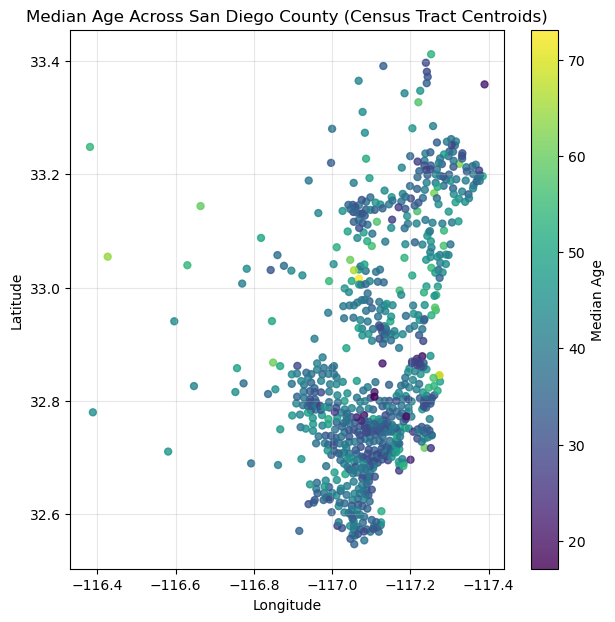

In [147]:
plt.figure(figsize=(7, 7))

# Use color to represent age
scatter = plt.scatter(
    acs["centroid_lon"],
    acs["centroid_lat"],
    c=acs["med_age"],
    cmap="viridis",
    s=25,
    alpha=0.8
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Median Age Across San Diego County (Census Tract Centroids)")
plt.gca().invert_xaxis()  # West (coast) on the left

# Colorbar legend
cbar = plt.colorbar(scatter)
cbar.set_label("Median Age")

plt.grid(alpha=0.3)
plt.show()

In [148]:
acs.isna().sum()

pop_total            0
med_income           0
med_age              0
white_alone          0
black_alone          0
asian_alone          0
hispanic_any         0
pop_below_poverty    0
NAME                 0
state                0
county               0
tract                0
GEOID                0
p_white              0
p_black              0
p_asian              0
p_hispanic           0
p_poverty            0
STATE                0
COUNTY               0
TRACT                0
centroid_lon         0
centroid_lat         0
region               0
dtype: int64

In [149]:
acs.to_csv("data/demographics.csv", index=False)

In [150]:
acs['pop_total'].max()

40481.0

## Cleaning Asthma Data

In [152]:
# Load in data
asthma = pd.read_csv('asthma.csv')

In [153]:
asthma.describe()

,Year,Zip_Code,Number_of_Asthma_ED_Visits,Age_Adjusted_Rate_of_Asthma_ED_V
count,12544.000000,12544.000000,12544.000000,12544.000000
mean,2017.927774,93220.995934,131.184471,40.267777
std,3.163016,1787.719672,133.187384,28.389523
min,2013.000000,90001.000000,12.000000,2.900000
25%,2015.000000,91915.000000,41.000000,21.400000
50%,2018.000000,93223.000000,85.000000,33.200000
75%,2021.000000,94931.000000,176.000000,50.700000
max,2023.000000,96161.000000,1130.000000,669.300000


In [154]:
asthma = asthma[(asthma['Year'] >= 2021) & (asthma['County'] == 'San Diego')]

In [155]:
asthma["Zip_Code"].unique()

array([91901, 91902, 91906, 91910, 91911, 91913, 91914, 91915, 91932,
       91935, 91941, 91942, 91945, 91950, 91977, 91978, 92008, 92009,
       92010, 92011, 92019, 92020, 92021, 92024, 92025, 92026, 92027,
       92028, 92029, 92040, 92054, 92056, 92057, 92058, 92064, 92065,
       92069, 92071, 92078, 92081, 92082, 92083, 92084, 92101, 92102,
       92103, 92104, 92105, 92106, 92107, 92108, 92109, 92110, 92111,
       92113, 92114, 92115, 92116, 92117, 92118, 92119, 92120, 92122,
       92123, 92124, 92126, 92127, 92128, 92129, 92130, 92131, 92139,
       92154, 92173, 92036, 92037, 92003, 92007, 92014])

In [156]:
asthma.isna().sum()

Year                                0
Zip_Code                            0
Number_of_Asthma_ED_Visits          0
Age_Adjusted_Rate_of_Asthma_ED_V    0
Age_Group                           0
County                              0
dtype: int64

In [157]:
asthma['Zip_Code'].nunique()

79

## Merge Asthma and Demographics Data

In [158]:
demo = pd.read_csv('data/demographics_zipcode.csv')

In [159]:
demo.columns

Index(['pop_total', 'med_income', 'med_age', 'white_alone', 'black_alone',
       'asian_alone', 'hispanic_any', 'pop_below_poverty', 'NAME', 'Zip_Code',
       'p_white', 'p_black', 'p_asian', 'p_hispanic', 'p_poverty'],
      dtype='object')

In [160]:
asthma = asthma.copy()
demo = demo.copy()

asthma["Zip_Code"] = asthma["Zip_Code"].astype(str).str.strip().str.zfill(5)
demo["Zip_Code"] = demo["Zip_Code"].astype(str).str.strip().str.zfill(5)

asthma_zips = set(asthma["Zip_Code"].unique())
demo_zips = set(demo["Zip_Code"].unique())

print("Asthma ZIPs:", len(asthma_zips))
print("Census ZIPs:", len(demo_zips))
print("Asthma ZIPs missing census data:", len(asthma_zips - demo_zips))

Asthma ZIPs: 79
Census ZIPs: 83
Asthma ZIPs missing census data: 0


In [161]:
merged = asthma.merge(
    demo,
    on="Zip_Code",
    how="left",
    validate="many_to_one"
)

assert merged.shape[0] == asthma.shape[0]
merged.head()

,Year,Zip_Code,Number_of_Asthma_ED_Visits,Age_Adjusted_Rate_of_Asthma_ED_V,Age_Group,County,pop_total,med_income,med_age,white_alone,black_alone,asian_alone,hispanic_any,pop_below_poverty,NAME,p_white,p_black,p_asian,p_hispanic,p_poverty
0,2021,91901,48,33.0,All Ages,San Diego,18300.0,116600.0,42.5,14504.0,310.0,474.0,3397.0,1845.0,ZCTA5 91901,0.792568,0.016940,0.025902,0.185628,0.100820
1,2021,91902,22,14.3,All Ages,San Diego,17445.0,121727.0,46.9,7318.0,255.0,2578.0,8241.0,1017.0,ZCTA5 91902,0.419490,0.014617,0.147779,0.472399,0.058298
2,2021,91906,14,38.7,All Ages,San Diego,3375.0,58561.0,44.9,2235.0,204.0,15.0,1016.0,507.0,ZCTA5 91906,0.662222,0.060444,0.004444,0.301037,0.150222
3,2021,91910,187,24.4,All Ages,San Diego,77957.0,87705.0,38.4,28568.0,2888.0,8215.0,50129.0,7978.0,ZCTA5 91910,0.366458,0.037046,0.105379,0.643034,0.102338
4,2021,91911,215,24.5,All Ages,San Diego,84619.0,79334.0,36.7,28566.0,3447.0,6106.0,63244.0,8862.0,ZCTA5 91911,0.337584,0.040736,0.072159,0.747397,0.104728


In [162]:
merged.columns

Index(['Year', 'Zip_Code', 'Number_of_Asthma_ED_Visits',
       'Age_Adjusted_Rate_of_Asthma_ED_V', 'Age_Group', 'County', 'pop_total',
       'med_income', 'med_age', 'white_alone', 'black_alone', 'asian_alone',
       'hispanic_any', 'pop_below_poverty', 'NAME', 'p_white', 'p_black',
       'p_asian', 'p_hispanic', 'p_poverty'],
      dtype='object')

<Axes: xlabel='Age_Adjusted_Rate_of_Asthma_ED_V', ylabel='Count'>

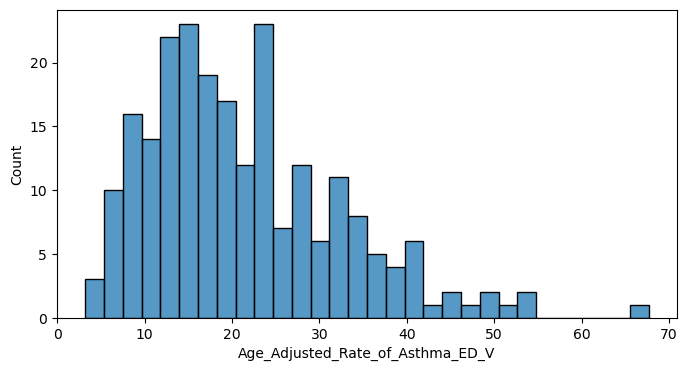

In [163]:
sns.histplot(merged["Age_Adjusted_Rate_of_Asthma_ED_V"], bins=30)

In [165]:
aqi_df['Local Site Name'].unique()

array(['Chula Vista', 'Alpine', 'Camp Pendleton', 'Donovan',
       'San Diego - Kearny Villa Rd.',
       'El Cajon - Lexington Elementary School',
       'San Diego - Sherman Elementary School', 'Pala Airpad',
       'La Posta Band of Indians'], dtype=object)

In [166]:
## Assign each zipcode to the closest AQI measuring station
demo["Zip_Code"] = demo["Zip_Code"].astype(str).str.strip().str.zfill(5)
asthma["Zip_Code"] = asthma["Zip_Code"].astype(str).str.strip().str.zfill(5)

# Only need centroids for ZIPs you actually have
zips = sorted(asthma["Zip_Code"].unique())

nomi = pgeocode.Nominatim("us")
geo = nomi.query_postal_code(zips)

zip_points = pd.DataFrame({
    "Zip_Code": zips,
    "centroid_lat": geo["latitude"].values,
    "centroid_lon": geo["longitude"].values
}).dropna(subset=["centroid_lat", "centroid_lon"])

print("ZIPs needed:", len(zips))
print("ZIPs with centroids found:", zip_points["Zip_Code"].nunique())
zip_points.head()

ZIPs needed: 79
ZIPs with centroids found: 79


,Zip_Code,centroid_lat,centroid_lon
0,91901,32.8282,-116.7543
1,91902,32.6671,-117.0221
2,91906,32.6605,-116.4905
3,91910,32.6371,-117.0676
4,91911,32.6084,-117.0565


In [168]:
aqi_stations = (
    aqi_df[["Site ID", "Local Site Name", "Site Latitude", "Site Longitude"]]
    .drop_duplicates()
    .rename(columns={
        "Site Latitude": "station_lat",
        "Site Longitude": "station_lon",
        "Local Site Name": "station_name",
        "Site ID": "station_id"
    })
    .reset_index(drop=True)
)

aqi_stations

,station_id,station_name,station_lat,station_lon
0,60730001,Chula Vista,32.631242,-117.059088
1,60731006,Alpine,32.842318,-116.768293
2,60731008,Camp Pendleton,33.217046,-117.396249
3,60731014,Donovan,32.578165,-116.921374
4,60731016,San Diego - Kearny Villa Rd.,32.845709,-117.123964
5,60731022,El Cajon - Lexington Elementary School,32.789565,-116.944308
6,60731026,San Diego - Sherman Elementary School,32.710177,-117.142665
7,60731201,Pala Airpad,33.362593,-117.090230
8,60739991,La Posta Band of Indians,32.725189,-116.364410


In [169]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

zip_points["_k"] = 1
aqi_stations["_k"] = 1
pairs = zip_points.merge(aqi_stations, on="_k").drop(columns="_k")

pairs["dist_km"] = haversine_km(
    pairs["centroid_lat"], pairs["centroid_lon"],
    pairs["station_lat"], pairs["station_lon"]
)

zip_to_station = (
    pairs.sort_values("dist_km")
         .groupby("Zip_Code", as_index=False)
         .first()[["Zip_Code", "station_id", "station_name", "dist_km"]]
)

zip_to_station.head()

,Zip_Code,station_id,station_name,dist_km
0,91901,60731006,Alpine,2.042945
1,91902,60730001,Chula Vista,5.281132
2,91906,60739991,La Posta Band of Indians,13.819061
3,91910,60730001,Chula Vista,1.029376
4,91911,60730001,Chula Vista,2.551453


In [170]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

station_year_aqi = (
    df.rename(columns={"Site ID": "station_id"})
      .groupby(["station_id", "Year"], as_index=False)["Daily AQI Value"]
      .mean()
      .rename(columns={"Daily AQI Value": "mean_aqi"})
)

station_year_aqi.head()

,station_id,Year,mean_aqi
0,60730001,2021,40.125698
1,60730001,2022,38.488506
2,60730001,2023,38.827298
3,60730001,2024,40.452722
4,60730001,2025,41.510067


In [171]:
station_year_aqi["Year"].min(), station_year_aqi["Year"].max()
station_year_aqi["station_id"].nunique()

9

In [172]:
zip_year_aqi = zip_to_station.merge(station_year_aqi, on="station_id", how="left")
zip_year_aqi.head()

,Zip_Code,station_id,station_name,dist_km,Year,mean_aqi
0,91901,60731006,Alpine,2.042945,2021,58.421348
1,91901,60731006,Alpine,2.042945,2022,59.253521
2,91901,60731006,Alpine,2.042945,2023,55.456825
3,91901,60731006,Alpine,2.042945,2024,58.446629
4,91901,60731006,Alpine,2.042945,2025,52.620896


In [173]:
zip_year_aqi.isna().sum().head()

Zip_Code        0
station_id      0
station_name    0
dist_km         0
Year            0
dtype: int64

In [174]:
final = merged.merge(
    zip_year_aqi[["Zip_Code", "Year", "mean_aqi", "station_name", "dist_km"]],
    on=["Zip_Code", "Year"],
    how="left",
    validate="many_to_one"
)

assert final.shape[0] == merged.shape[0]
final[["Zip_Code", "Year", "mean_aqi", "station_name", "dist_km"]].head()

,Zip_Code,Year,mean_aqi,station_name,dist_km
0,91901,2021,58.421348,Alpine,2.042945
1,91902,2021,40.125698,Chula Vista,5.281132
2,91906,2021,NaN,NaN,NaN
3,91910,2021,40.125698,Chula Vista,1.029376
4,91911,2021,40.125698,Chula Vista,2.551453


In [175]:
# Drop missing values because there are very few of them and correspond to very rural and uninhabited zip codes in eastern SD county
model_df = final.dropna(subset=["mean_aqi"]).copy()

<Axes: xlabel='mean_aqi', ylabel='Age_Adjusted_Rate_of_Asthma_ED_V'>

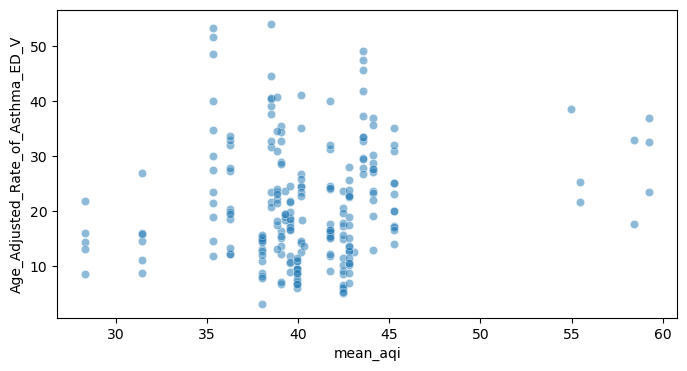

In [176]:
sns.scatterplot(
    data=model_df,
    x="mean_aqi",
    y="Age_Adjusted_Rate_of_Asthma_ED_V",
    alpha=0.5
)

In [177]:
formula = (
    "Age_Adjusted_Rate_of_Asthma_ED_V ~ "
    "mean_aqi + med_income + p_poverty + p_hispanic + p_black + Year"
)

model = smf.ols(
    formula,
    data=model_df
).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                   OLS Regression Results                                   
============================================================================================
Dep. Variable:     Age_Adjusted_Rate_of_Asthma_ED_V   R-squared:                       0.551
Model:                                          OLS   Adj. R-squared:                  0.539
Method:                               Least Squares   F-statistic:                     44.81
Date:                              Sat, 13 Dec 2025   Prob (F-statistic):           1.54e-35
Time:                                      04:58:10   Log-Likelihood:                -762.13
No. Observations:                               226   AIC:                             1538.
Df Residuals:                                   219   BIC:                             1562.
Df Model:                                         6                                         
Covariance Type:                          nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1416.1315   1180.569     -1.200      0.232   -3742.863     910.600
mean_aqi       0.5480      0.107      5.128      0.000       0.337       0.759
med_income -6.046e-05   2.76e-05     -2.193      0.029      -0.000   -6.13e-06
p_poverty     54.5790     16.689      3.270      0.001      21.688      87.470
p_hispanic     6.9976      3.436      2.036      0.043       0.226      13.770
p_black      121.2718     14.761      8.216      0.000      92.180     150.364
Year           0.6966      0.584      1.193      0.234      -0.454       1.847
==============================================================================
Omnibus:                        7.328   Durbin-Watson:                   1.319
Prob(Omnibus):                  0.026   Jarque-Bera (JB):                7.208
Skew:                           0.373   Prob(JB):                       0.0272
Kurtosis:                       3.458   Cond. No.                     2.78e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.78e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.78e+08. This might indicate that there are
strong multicollinearity or other numerical problems.

In [178]:
## Cook's Distance to test outlier influence
influence = model.get_influence()
cooks = influence.cooks_distance[0]

model_df["cooks_d"] = cooks
#model_df.sort_values("cooks_d", ascending=False).head()

cooks = model_df[model_df['mean_aqi'] > 50][['mean_aqi', 'cooks_d']]
cooks['Is_Influential'] = cooks['cooks_d'].apply(lambda x: x > (4/model_df.shape[0]))
cooks

,mean_aqi,cooks_d,Is_Influential
0,58.421348,1.535442e-02,False
35,58.421348,7.693808e-03,False
74,59.253521,9.547439e-03,False
103,59.253521,2.222750e-02,True
111,59.253521,5.657658e-05,False
150,55.456825,3.583413e-09,False
152,54.996951,3.321254e-04,False
189,55.456825,1.908084e-04,False


## Regression Analysis Plots

In [179]:
model_df["fitted"] = model.fittedvalues

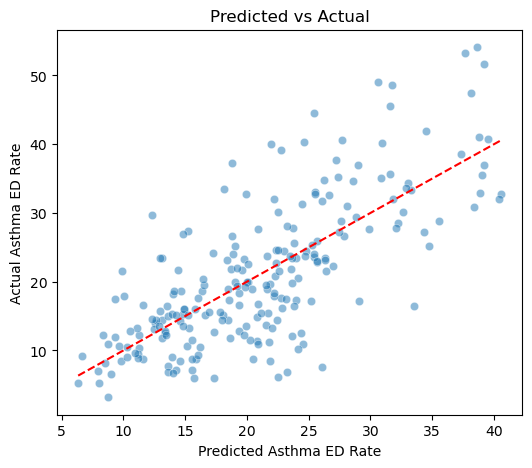

In [180]:
model_df["fitted"] = model.fittedvalues

plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=model_df["fitted"],
    y=model_df["Age_Adjusted_Rate_of_Asthma_ED_V"],
    alpha=0.5
)
plt.plot(
    [model_df["fitted"].min(), model_df["fitted"].max()],
    [model_df["fitted"].min(), model_df["fitted"].max()],
    color="red",
    linestyle="--"
)
plt.xlabel("Predicted Asthma ED Rate")
plt.ylabel("Actual Asthma ED Rate")
plt.title("Predicted vs Actual")
plt.show()

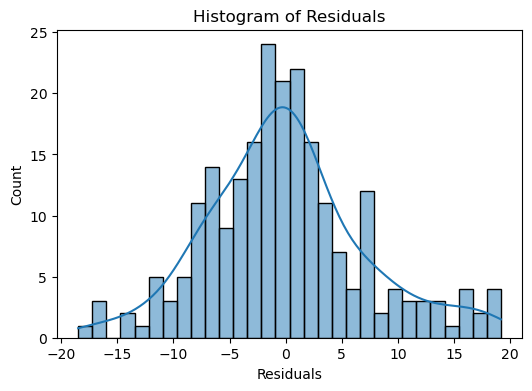

In [181]:
residuals = model.resid

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.show()

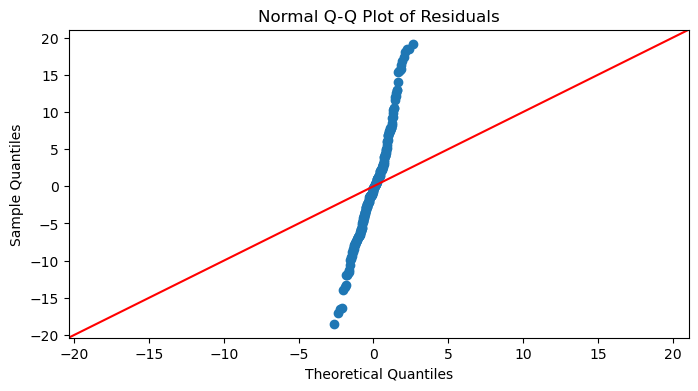

In [182]:
sm.qqplot(residuals, line="45")
plt.title("Normal Q-Q Plot of Residuals")
plt.show()

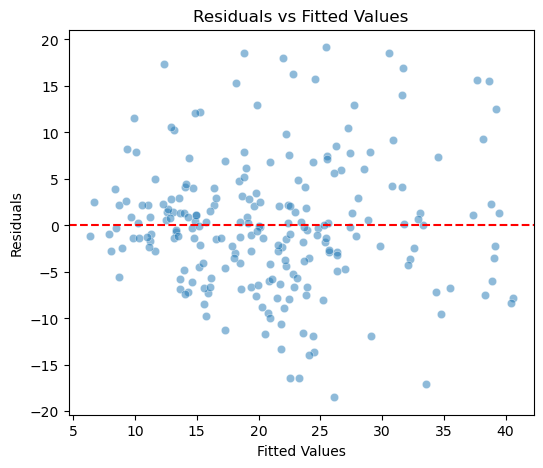

In [183]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=model_df["fitted"],
    y=residuals,
    alpha=0.5
)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

In [186]:
model_robust = smf.ols(formula, data=model_df).fit(cov_type="HC3")
model_robust.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                   OLS Regression Results                                   
============================================================================================
Dep. Variable:     Age_Adjusted_Rate_of_Asthma_ED_V   R-squared:                       0.551
Model:                                          OLS   Adj. R-squared:                  0.539
Method:                               Least Squares   F-statistic:                     46.54
Date:                              Sat, 13 Dec 2025   Prob (F-statistic):           1.59e-36
Time:                                      04:58:41   Log-Likelihood:                -762.13
No. Observations:                               226   AIC:                             1538.
Df Residuals:                                   219   BIC:                             1562.
Df Model:                                         6                                         
Covariance Type:                                HC3                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1416.1315   1027.789     -1.378      0.168   -3430.561     598.298
mean_aqi       0.5480      0.094      5.801      0.000       0.363       0.733
med_income -6.046e-05   2.93e-05     -2.063      0.039      -0.000   -3.02e-06
p_poverty     54.5790     22.963      2.377      0.017       9.572      99.586
p_hispanic     6.9976      4.058      1.724      0.085      -0.957      14.952
p_black      121.2718     18.107      6.698      0.000      85.783     156.760
Year           0.6966      0.509      1.368      0.171      -0.301       1.694
==============================================================================
Omnibus:                        7.328   Durbin-Watson:                   1.319
Prob(Omnibus):                  0.026   Jarque-Bera (JB):                7.208
Skew:                           0.373   Prob(JB):                       0.0272
Kurtosis:                       3.458   Cond. No.                     2.78e+08
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 2.78e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## EDA for Asthma Data

In [187]:
asthma_sd[['Number_of_Asthma_ED_Visits', 'Age_Adjusted_Rate_of_Asthma_ED_V']].describe()

,Number_of_Asthma_ED_Visits,Age_Adjusted_Rate_of_Asthma_ED_V
count,842.000000,842.000000
mean,119.515439,28.304751
std,107.411387,16.714281
min,12.000000,3.200000
25%,47.000000,16.200000
50%,82.000000,23.700000
75%,150.000000,35.350000
max,584.000000,107.200000


In [188]:
asthma_sd.head()

,Year,Zip_Code,Number_of_Asthma_ED_Visits,Age_Adjusted_Rate_of_Asthma_ED_V,Age_Group,County
280,2013,91901,52,34.9,All Ages,San Diego
281,2013,91902,55,33.4,All Ages,San Diego
282,2013,91906,25,74.7,All Ages,San Diego
283,2013,91910,375,50.6,All Ages,San Diego
284,2013,91911,528,61.9,All Ages,San Diego


Text(0.5, 1.0, 'Total Number of Asthma ED Visits for Each Zip Code by Year')

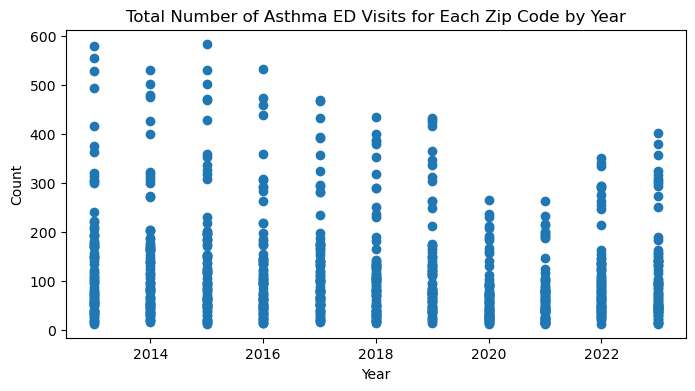

In [189]:
plt.scatter(asthma_sd['Year'], asthma_sd['Number_of_Asthma_ED_Visits'])
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Total Number of Asthma ED Visits for Each Zip Code by Year')

## ANOVA Testing for AQI Between the 10 Most Populated Coastal and Inland Zip Codes

### Checking Conditions

In order to do ANOVA testing, the data must fulfill 3 conditions.

First, each observation must be independent. This can be reasonably assumed to be fulfilled even though there are broader trends within the AQI score for each date, because our ANOVA testing does not discern based on date.

Next, the dependent variable must be normally distributed. We can check that with a histogram below. While the data has a slight right skew, it is not too far from having a Gaussian distribution, and thus this condition can be considered to be met.

Third, the variability between each group must be similar. This can be checked with a box plot below. The variability for Petco Park and La Jolla appear to be higher than the other regions. In order to mitigate this, we should drop outliers.

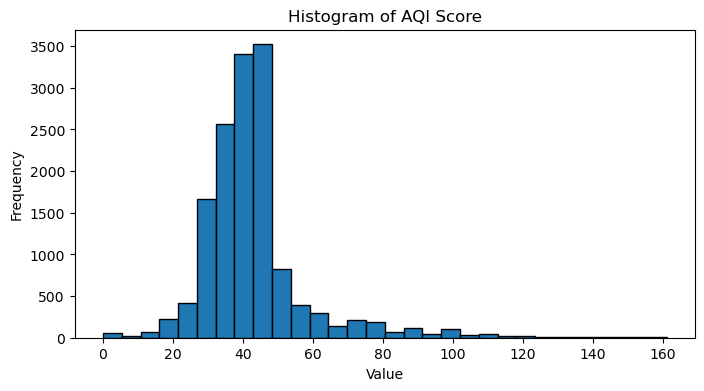

In [190]:
plt.hist(aqi_df['Daily AQI Value'], bins=30, edgecolor='black') # bins argument controls the number of bins
plt.title('Histogram of AQI Score')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

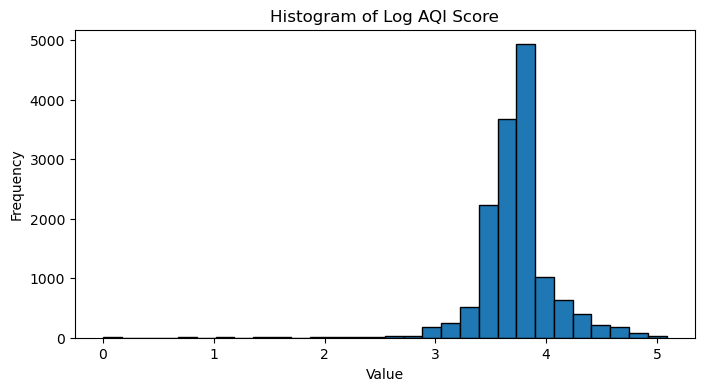

In [191]:
aqi_df['log_aqi'] = np.log1p(aqi_df['Daily AQI Value'])

plt.hist(aqi_df['log_aqi'], bins=30, edgecolor='black') # bins argument controls the number of bins
plt.title('Histogram of Log AQI Score')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

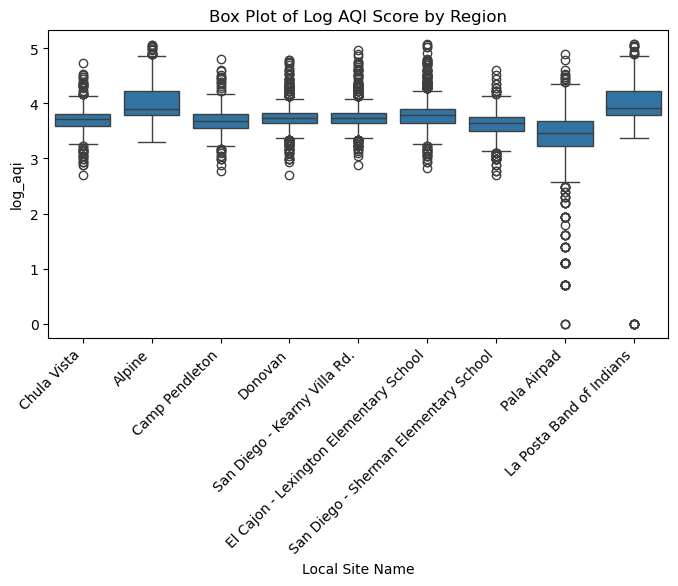

In [192]:
sns.boxplot(x='Local Site Name', y='log_aqi', data=aqi_df.reset_index())
plt.title('Box Plot of Log AQI Score by Region')
plt.xticks(rotation=45, ha='right')
plt.show()

In [193]:
regions = aqi_df['Local Site Name'].unique()

chula = np.array(aqi_df[aqi_df['Local Site Name']=='Chula Vista']['log_aqi'])
alpine = np.array(aqi_df[aqi_df['Local Site Name']=='Alpine']['log_aqi'])
pendleton = np.array(aqi_df[aqi_df['Local Site Name']=='Camp Pendleton']['log_aqi'])
donovan = np.array(aqi_df[aqi_df['Local Site Name']=='Donovan']['log_aqi'])
kearny = np.array(aqi_df[aqi_df['Local Site Name']=='San Diego - Kearny Villa Rd.']['log_aqi'])
cajon = np.array(aqi_df[aqi_df['Local Site Name']=='El Cajon - Lexington Elementary School']['log_aqi'])
sherman = np.array(aqi_df[aqi_df['Local Site Name']=='San Diego - Sherman Elementary School']['log_aqi'])
pala = np.array(aqi_df[aqi_df['Local Site Name']=='Pala Airpad']['log_aqi'])
la_posta = np.array(aqi_df[aqi_df['Local Site Name']=='La Posta Band of Indians']['log_aqi'])

In [194]:
f_statistic, p_value = stats.f_oneway(chula, alpine, pendleton, donovan, kearny, cajon, sherman, pala, la_posta)

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")

F-statistic: 548.5690908436666
P-value: 0.0


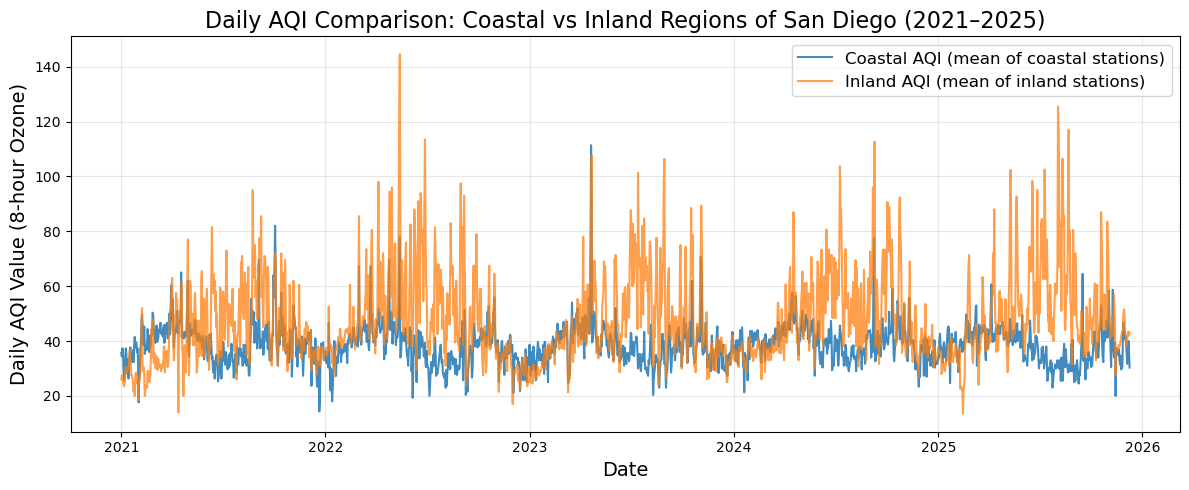

In [195]:
pivot = df.pivot_table(
    index='Date',
    columns='Local Site Name',
    values='Daily AQI Value'
)

coastal = pivot[coastal_stations].mean(axis=1)
inland  = pivot[inland_stations].mean(axis=1)

coastal_smooth = coastal.rolling(window=7, center=True).mean()
inland_smooth = inland.rolling(window=7, center=True).mean()

plt.figure(figsize=(12,5))

plt.plot(coastal, label="Coastal AQI (mean of coastal stations)", alpha=0.85)
plt.plot(inland, label="Inland AQI (mean of inland stations)", alpha=0.75)

plt.title("Daily AQI Comparison: Coastal vs Inland Regions of San Diego (2021–2025)", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Daily AQI Value (8-hour Ozone)", fontsize=14)

plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## T-Test and Bootstrapping Analysis

Because the main question that we want to answer is if the distributions of AQI for coastal and inland regions, which are essentially two large samples, are different, we will do a 2 sample T-test, using Welch's correction, as the variances are different. 

In [196]:
## Obtaining coastal and inland AQI distribution arrays
coastal = aqi_df[aqi_df['Coastal']==1]['Daily AQI Value']
inland = aqi_df[aqi_df['Inland']==1]['Daily AQI Value']

## 2 Sample T-Test
result = pg.ttest(coastal, inland, correction=True)
print(result)

               T          dof alternative          p-val          CI95%  \
T-test -24.86141  5287.111907   two-sided  3.945696e-129  [-9.72, -8.3]   

         cohen-d        BF10  power  
T-test  0.543345  1.493e+128    1.0  


In [197]:
## sampling from inland n times and coastal n times, both with replacement. 
## Then you plot a histogram for both and you should get a bell curve for both. 
## Then you layer one over the other and one should be shifted compared to the other
iters = 1000
coastal_boot = []
for _ in range(iters):
    bootstrap_sample = np.random.choice(coastal, size=len(coastal), replace=True)
    coastal_boot.append(bootstrap_sample.mean())

inland_boot = []
for _ in range(iters):
    bootstrap_sample = np.random.choice(inland, size=len(inland), replace=True)
    inland_boot.append(bootstrap_sample.mean())

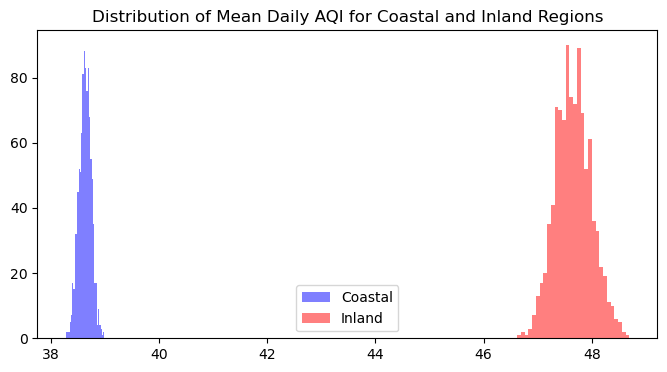

In [198]:
plt.hist(coastal_boot, bins=30, alpha=0.5, label='Coastal', color='blue')
plt.hist(inland_boot, bins=30, alpha=0.5, label='Inland', color='red')
plt.title('Distribution of Mean Daily AQI for Coastal and Inland Regions')
plt.legend()